In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data sources:
- https://openjustice.doj.ca.gov/data
- https://datacenter.aecf.org/data/customreports/1/103

In [2]:
felony = pd.read_csv("data/felony_data.csv")
felony.head(10)

,RACE_DESC,COUNT OF FELONIES,% OF FELONIES,YEAR
0,Asian/Pacific Islander,1048,2.504601,2012
1,Other,1266,3.025596,2012
2,White,7904,18.889659,2012
3,Black,9397,22.457759,2012
4,Hispanic,22228,53.122386,2012
5,Asian/Pacific Islander,928,2.476384,2013
6,Other,1005,2.681859,2013
7,White,6757,18.031168,2013
8,Black,8830,23.563004,2013
9,Hispanic,19954,53.247585,2013


In [3]:
felony.dtypes

RACE_DESC                str
COUNT OF FELONIES      int64
% OF FELONIES        float64
YEAR                   int64
dtype: object

In [4]:
children = pd.read_csv("data/child_demographics_clean.csv")
children.head(10)

,RACE_DESC,Year,Population Count,% of Population
0,Asian/Pacific Islander,2019,4065560,5.562503
1,Asian/Pacific Islander,2021,4171342,5.664553
2,Asian/Pacific Islander,2022,4239493,5.775625
3,Asian/Pacific Islander,2023,4325923,5.904213
4,Asian/Pacific Islander,2024,4434461,6.063580
5,Black,2019,10034057,13.728607
6,Black,2021,10162116,13.799838
7,Black,2022,10156681,13.836839
8,Black,2023,10151595,13.855350
9,Black,2024,10138247,13.862806


In [5]:
children.dtypes

RACE_DESC               str
Year                  int64
Population Count      int64
% of Population     float64
dtype: object

In [6]:
df = felony.merge(
    children,
    left_on=["RACE_DESC","YEAR"],
    right_on=["RACE_DESC","Year"],
    how="right" # ignore felony data from years not in gen demgraph data
)

df = df.drop(columns=["YEAR"])
df.sort_values(by=["Year", "Population Count"], inplace=True)
df

,RACE_DESC,COUNT OF FELONIES,% OF FELONIES,Year,Population Count,% of Population
15,Other,933,4.162577,2019,3912572,5.353185
0,Asian/Pacific Islander,472,2.105827,2019,4065560,5.562503
5,Black,5795,25.854377,2019,10034057,13.728607
10,Hispanic,11889,53.042741,2019,18588264,25.432482
20,White,3325,14.834478,2019,36488222,49.923223
16,Other,661,4.548895,2021,4029788,5.472327
1,Asian/Pacific Islander,310,2.133370,2021,4171342,5.664553
6,Black,3608,24.829674,2021,10162116,13.799838
11,Hispanic,7793,53.630170,2021,19069207,25.895392
21,White,2159,14.857890,2021,36206931,49.167890


In [7]:
totals = felony.groupby("YEAR")["COUNT OF FELONIES"].sum()

**Null Hypothesis**
The proportion of Hispanic minors in the population is proportionate/equal to the occurence of felony cases that are Hispanic.

**Alternative Hypothesis**
The proportion of Hispanic minors in the population is disproportionate to the occurence of felony cases that are Hispanic.
Specifically, the % of felony cases that are Hispanic is GREATER than the % of Hispanic minors.

In [8]:
from scipy.stats import norm
import numpy as np

results = []

for year in df["Year"].unique():
    print(f"Processing Year {year}")
    year_df = df[df["Year"] == year]

    # total felony cases
    n = totals.loc[year]

    # observed Hispanic felony count
    hisp_count = year_df.loc[
        year_df["RACE_DESC"] == "Hispanic",
        "COUNT OF FELONIES"
    ].values[0]

    # observed proportion vs "expected"
    p_hat = hisp_count / n

    p0 = year_df.loc[
        year_df["RACE_DESC"] == "Hispanic",
        "% of Population"
    ].values[0] / 100

    # z statistic
    z = (p_hat - p0) / np.sqrt((p0 * (1 - p0)) / n)

    # one-sided p-value
    p_value = 1 - norm.cdf(z)

    results.append({
        "Year": year,
        "Observed %": p_hat,
        "Expected %": p0,
        "Z": z,
        "p-value": p_value
    })

p_tests = pd.DataFrame(results)

Processing Year 2019
Processing Year 2021
Processing Year 2022
Processing Year 2023
Processing Year 2024


In [14]:
p_tests["Disparity"] = p_tests["Observed %"] / p_tests["Expected %"]
p_tests

,Year,Observed %,Expected %,Z,p-value,Disparity
0,2019,0.530427,0.254325,94.920705,0.0,2.085630
1,2021,0.536302,0.258954,76.320041,0.0,2.071031
2,2022,0.548228,0.262073,82.380130,0.0,2.091888
3,2023,0.561849,0.265664,95.006909,0.0,2.114884
4,2024,0.564014,0.269221,98.410053,0.0,2.094986


Population Simulations:

In [16]:
def population_sim(year):
    year_df = df[df["Year"] == year]
    n = year_df["COUNT OF FELONIES"].sum()
    
    # expected vs observed % Hispanic from population
    p0 = year_df.loc[
        year_df["RACE_DESC"] == "Hispanic",
        "% of Population"
    ].iloc[0] / 100 # bring down to fractional value
    
    p_hat = year_df.loc[
        year_df["RACE_DESC"] == "Hispanic",
        "COUNT OF FELONIES"
    ].iloc[0] / n
    
    num_sims = 10_000
    sim_counts = np.random.binomial(n, p0, size=num_sims)
    sim_props = sim_counts / n
    
    p_value = np.mean(sim_props >= p_hat)
    print("Observed Hispanic felony proportion:", p_hat)
    print("Expected Hispanic population proportion:", p0)
    print("p-value:", p_value)
    
    # plot
    plt.figure(figsize=(8,5))
    plt.hist(sim_props, bins=15, edgecolor="black")
    plt.axvline(p_hat, linewidth=2, label=f"Observed {year} felony % = {p_hat:.3f}")
    plt.xlabel("Simulated Hispanic felony proportion")
    plt.ylabel("Frequency")
    plt.title(f"{year} Null Distribution of Hispanic Felony Proportion")
    plt.legend()
    plt.tight_layout()
    plt.show()

Observed Hispanic felony proportion: 0.5304274114392791
Expected Hispanic population proportion: 0.2543248184482753
p-value: 0.0


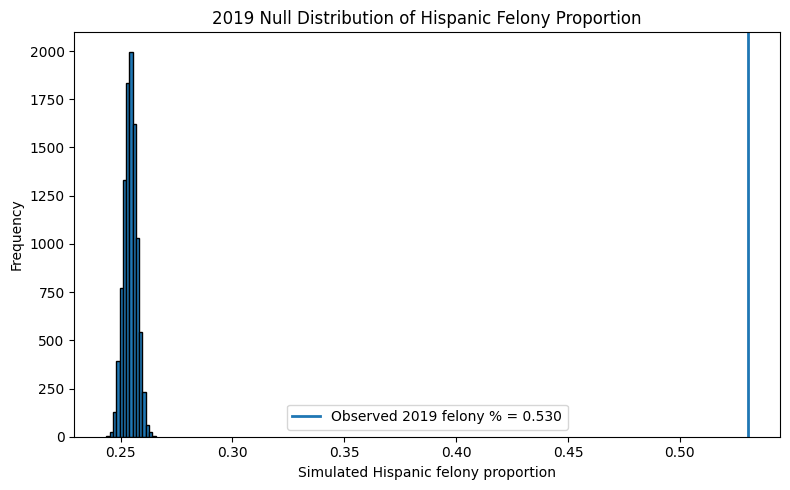

Observed Hispanic felony proportion: 0.5363016998141904
Expected Hispanic population proportion: 0.2589539179197914
p-value: 0.0


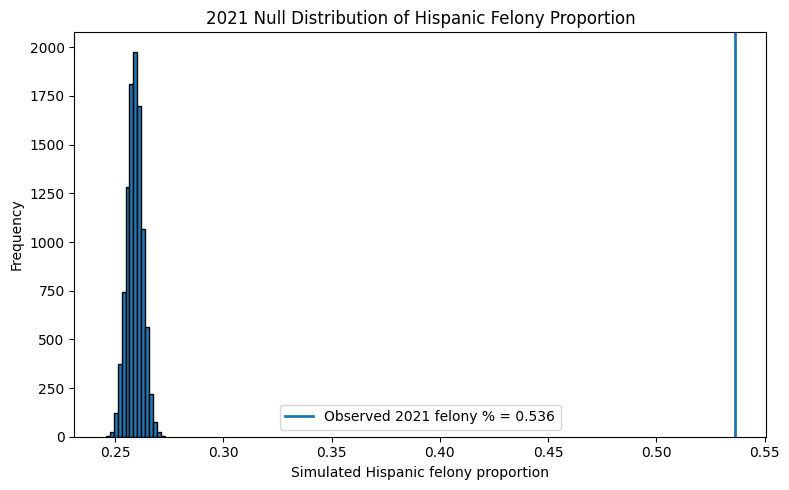

Observed Hispanic felony proportion: 0.5482281008235588
Expected Hispanic population proportion: 0.2620734129422281
p-value: 0.0


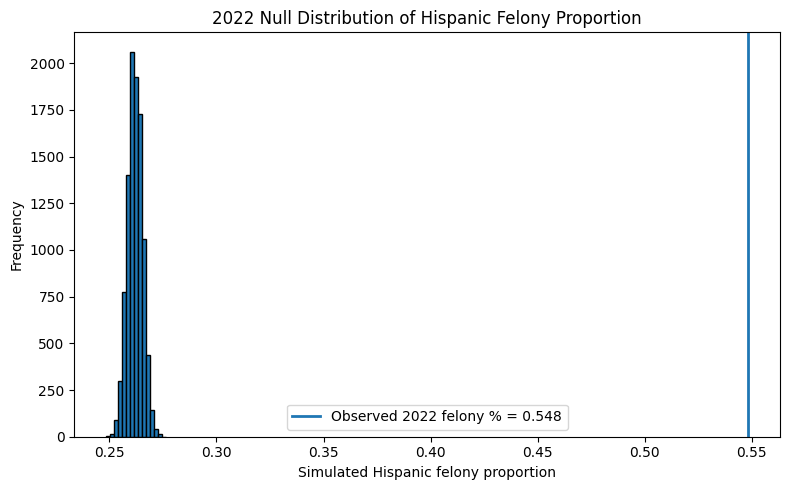

Observed Hispanic felony proportion: 0.5618492502366362
Expected Hispanic population proportion: 0.265664311149627
p-value: 0.0


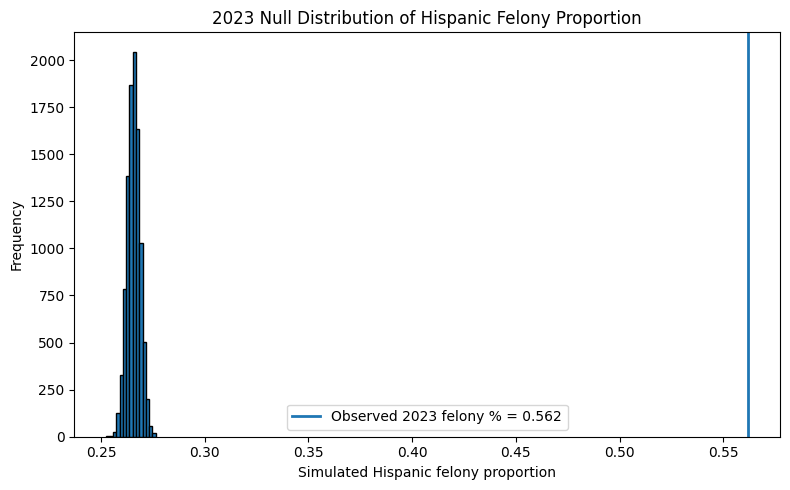

Observed Hispanic felony proportion: 0.5640136830102622
Expected Hispanic population proportion: 0.269220767393856
p-value: 0.0


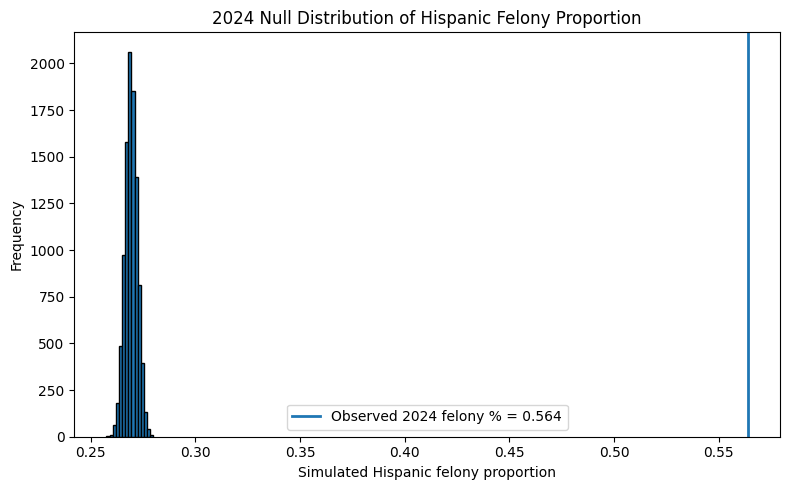

In [18]:
for year in df["Year"].unique():
    population_sim(year)